In [1]:
import random
from pathlib import Path

import albumentations as A
import cv2
import numpy as np
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm.notebook import trange

In [2]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
set_seed(42)

In [4]:
class DCA1Dataset(Dataset):
    def __init__(
        self,
        image_dir: str,
        stems: list[str] = None,
        transform=None,
    ) -> None:
        self.image_dir = Path(image_dir)
        self.stems = stems
        self.transform = transform

    def __len__(self) -> int:
        return len(self.stems)

    def __getitem__(self, idx: int):
        stem = self.stems[idx]

        img_path = self.image_dir / f"{stem}.pgm"
        mask_path = self.image_dir / f"{stem}_gt.pgm"

        image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        image = image.astype(np.float32) / 255.0
        mask = (mask > 127).astype(np.float32)

        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        image = np.expand_dims(image, axis=0)  # [1, H, W]
        mask = np.expand_dims(mask, axis=0)  # [1, H, W]

        return torch.from_numpy(image).float(), torch.from_numpy(mask).float()

In [5]:
def get_train_transforms(img_size: int):
    return A.Compose(
        [
            A.Resize(img_size, img_size, interpolation=cv2.INTER_AREA),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.1),
            A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT, p=0.3),
            A.RandomBrightnessContrast(
                brightness_limit=0.15,
                contrast_limit=0.15,
                p=0.3,
            ),
            A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        ]
    )


def get_val_transforms(img_size: int):
    return A.Compose(
        [
            A.Resize(img_size, img_size, interpolation=cv2.INTER_AREA),
        ]
    )

In [6]:
class CoronaryUNet(nn.Module):
    def __init__(
        self, encoder_name: str = "resnet34", encoder_weights: str = "imagenet"
    ):
        super().__init__()
        self.model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=1,
            classes=1,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    @torch.no_grad()
    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        logits = self.forward(x)
        return torch.sigmoid(logits)

    @torch.no_grad()
    def predict_mask(self, x: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
        probs = self.predict_proba(x)
        return (probs > threshold).float()

In [7]:
class BCEDiceCriterion(nn.Module):
    def __init__(self, bce_weight: float = 0.5, dice_weight: float = 0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)

    def forward(self, logits: torch.Tensor, masks: torch.Tensor) -> torch.Tensor:
        bce_loss = self.bce(logits, masks)
        dice_loss = self.dice(logits, masks)
        return self.bce_weight * bce_loss + self.dice_weight * dice_loss

In [8]:
def compute_smp_metrics(
    logits: torch.Tensor, masks: torch.Tensor, threshold: float = 0.5
) -> tuple[float, float]:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).long()
    targets = masks.long()

    tp, fp, fn, tn = smp.metrics.get_stats(
        preds,
        targets,
        mode="binary",
    )

    iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
    dice = smp.metrics.f1_score(tp, fp, fn, tn, reduction="micro")

    return dice.item(), iou.item()

In [9]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
):
    model.train()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        bs = images.size(0)
        dice, iou = compute_smp_metrics(logits.detach(), masks)

        total_loss += loss.item() * bs
        total_dice += dice * bs
        total_iou += iou * bs
        total_samples += bs

    return (
        total_loss / total_samples,
        total_dice / total_samples,
        total_iou / total_samples,
    )

In [10]:
@torch.no_grad()
def validate_one_epoch(
    model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device
):
    model.eval()

    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    total_samples = 0

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)

        bs = images.size(0)
        dice, iou = compute_smp_metrics(logits, masks)

        total_loss += loss.item() * bs
        total_dice += dice * bs
        total_iou += iou * bs
        total_samples += bs

    return (
        total_loss / total_samples,
        total_dice / total_samples,
        total_iou / total_samples,
    )

In [11]:
def training_loop(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
    num_epochs: int = 20,
    scheduler: torch.optim.lr_scheduler._LRScheduler | None = None,
):
    best_val_loss = float("inf")
    best_model_state = None
    epoch_bar = trange(1, num_epochs + 1, desc="Epochs")
    history = {
        "train_loss": [],
        "train_dice": [],
        "train_iou": [],
        "val_loss": [],
        "val_dice": [],
        "val_iou": [],
    }

    for _ in epoch_bar:
        train_loss, train_dice, train_iou = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_dice, val_iou = validate_one_epoch(
            model, val_loader, criterion, device
        )

        if scheduler is not None:
            scheduler.step(val_dice)

        epoch_bar.set_postfix(
            train_loss=f"{train_loss:.4f}",
            train_dice=f"{train_dice:.4f}",
            val_loss=f"{val_loss:.4f}",
            val_dice=f"{val_dice:.4f}",
        )

        history["train_loss"].append(train_loss)
        history["train_dice"].append(train_dice)
        history["train_iou"].append(train_iou)
        history["val_loss"].append(val_loss)
        history["val_dice"].append(val_dice)
        history["val_iou"].append(val_iou)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return history

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
def get_stems_from_dir(image_dir: str) -> list[str]:
    image_dir = Path(image_dir)
    stems = []
    for img_path in image_dir.glob("*.pgm"):
        if img_path.name.endswith("_gt.pgm"):
            continue
        stem = img_path.stem
        stems.append(stem)
    return stems

In [14]:
IMAGE_DIR = "raw_datasets/DCA1/Database_134_Angiograms"
stems = get_stems_from_dir(IMAGE_DIR)

train_stems, val_stems = train_test_split(stems, test_size=0.2, random_state=42)

In [15]:
BATCH_SIZE = 8
IMG_SIZE = 320

train_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    stems=train_stems,
    transform=get_train_transforms(IMG_SIZE),
)
val_ds = DCA1Dataset(
    image_dir=IMAGE_DIR,
    stems=val_stems,
    transform=get_val_transforms(IMG_SIZE),
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

In [16]:
LR = 1e-3
WEIGHT_DECAY = 1e-4


model = CoronaryUNet(encoder_name="resnet50").to(device)
criterion = BCEDiceCriterion(bce_weight=0.5, dice_weight=0.5)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

In [17]:
history = training_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    num_epochs=50,
    scheduler=scheduler,
)

Epochs:   0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# TODO: threshold tuning

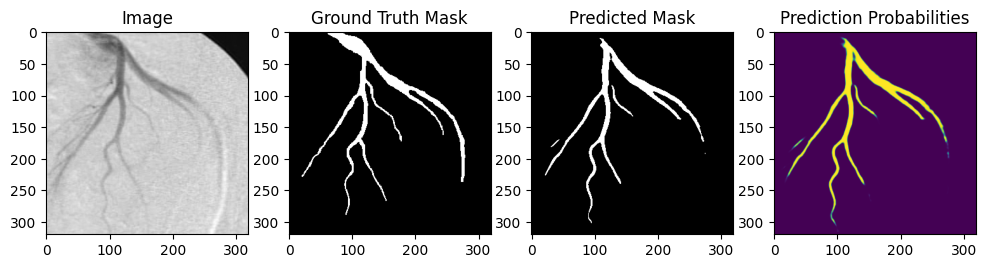

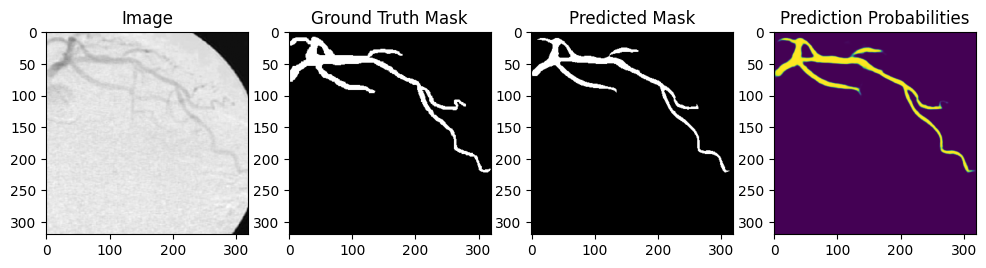

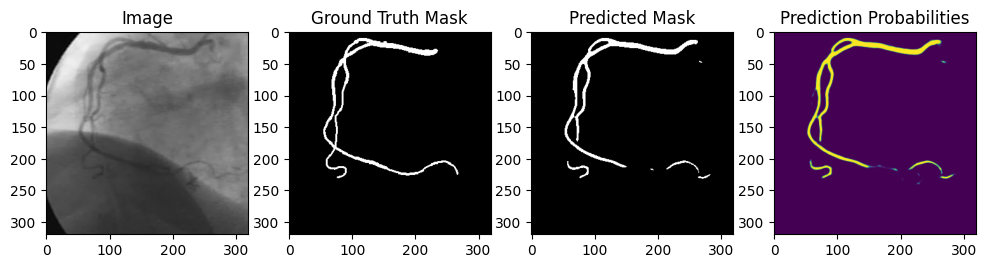

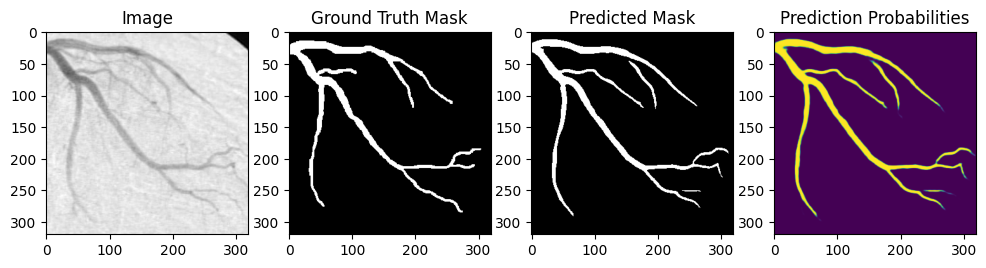

In [25]:
model.eval()

with torch.no_grad():
    val_loader_iter = iter(val_loader)
    for i in range(5 // BATCH_SIZE + 1):
        images, masks = next(val_loader_iter)
        images = images.to(device)
        masks = masks.to(device)

        probs = model.predict_proba(images)
        preds = (probs > 0.5).float()

        for i in range(min(4, images.size(0))):
            img = images[i, 0].cpu().numpy()
            mask = masks[i, 0].cpu().numpy()
            pred = preds[i, 0].cpu().numpy()
            prob = probs[i, 0].cpu().numpy()

            fig, axes = plt.subplots(1, 4, figsize=(12, 4))
            axes[0].imshow(img, cmap="gray")
            axes[0].set_title("Image")
            axes[1].imshow(mask, cmap="gray")
            axes[1].set_title("Ground Truth Mask")
            axes[2].imshow(pred, cmap="gray")
            axes[2].set_title("Predicted Mask")
            axes[3].imshow(prob)
            axes[3].set_title("Prediction Probabilities")
            plt.show()

In [19]:
# val metrics

with torch.no_grad():
    val_loss, val_dice, val_iou = validate_one_epoch(
        model, val_loader, criterion, device
    )
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Dice Coefficient: {val_dice:.4f}")
    print(f"Validation IoU: {val_iou:.4f}")

Validation Loss: 0.1728
Validation Dice Coefficient: 0.7629
Validation IoU: 0.6169


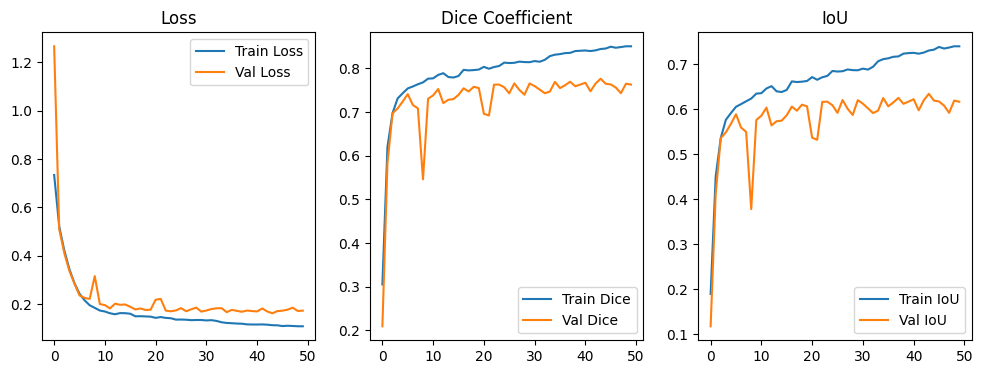

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_dice"], label="Train Dice")
axes[1].plot(history["val_dice"], label="Val Dice")
axes[1].set_title("Dice Coefficient")
axes[1].legend()

axes[2].plot(history["train_iou"], label="Train IoU")
axes[2].plot(history["val_iou"], label="Val IoU")
axes[2].set_title("IoU")
axes[2].legend()

plt.show()

In [21]:
import os

if not os.path.exists("output"):
    os.makedirs("output")

torch.save(model.state_dict(), "output/best_coronary_unet.pth")

In [22]:
# TODO: utilize pretraining from ARCADE